In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_ROOT = Path.cwd().parent

ratings = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "ratings.csv"
)

movies = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "movies.csv"
)

print("Ratings:", ratings.shape)
print("Movies:", movies.shape)

Ratings: (100000, 4)
Movies: (1682, 5)


### Convert timestamps

In [2]:
ratings["datetime"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

ratings[["timestamp", "datetime"]].head()

,timestamp,datetime
0,881250949,1997-12-04 15:55:49
1,891717742,1998-04-04 19:22:22
2,878887116,1997-11-07 07:18:36
3,880606923,1997-11-27 05:02:03
4,886397596,1998-02-02 05:33:16


In [3]:
print("First rating:", ratings["datetime"].min())
print("Last rating:", ratings["datetime"].max())

First rating: 1997-09-20 03:05:10
Last rating: 1998-04-22 23:10:38


### Analyze rating distribution

In [4]:
rating_distribution = (
    ratings["rating"]
    .value_counts()
    .sort_index()
)

print(rating_distribution)

rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


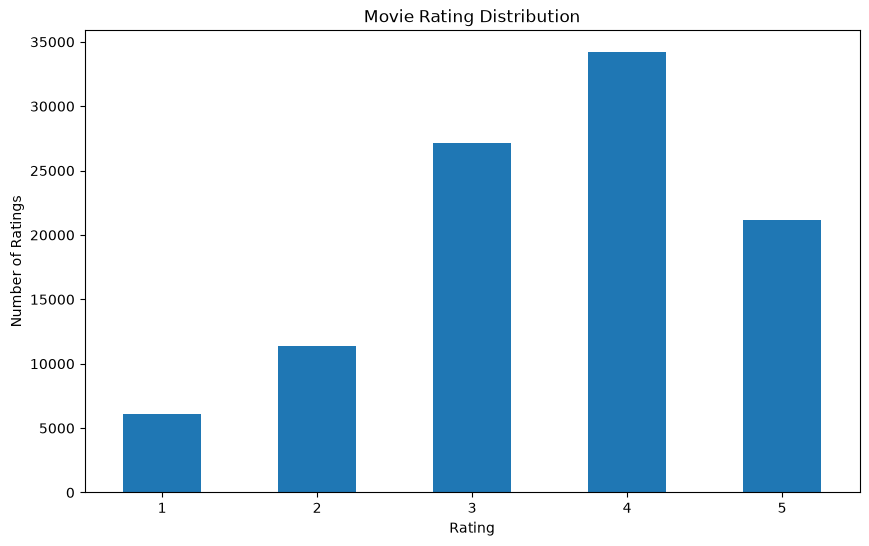

In [5]:
rating_distribution.plot(kind="bar")

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()


### Analyze user activity

In [6]:
user_activity = (
    ratings.groupby("user_id")
    .size()
    .sort_values(ascending=False)
)

user_activity.head(10)

user_id
405    737
655    685
13     636
450    540
276    518
416    493
537    490
303    484
234    480
393    448
dtype: int64

In [7]:
print(user_activity.describe())

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64


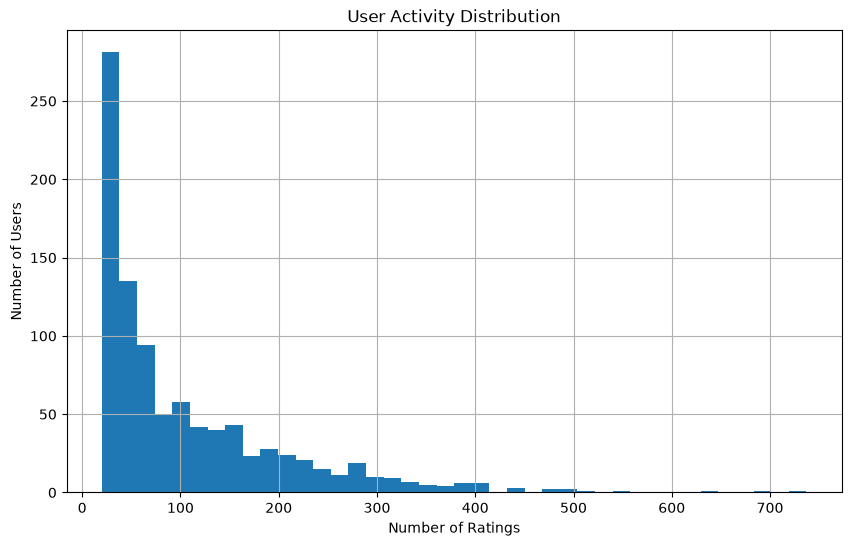

In [8]:
user_activity.hist(bins=40)

plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

### Analyze movie popularity

In [9]:
movie_popularity = (
    ratings.groupby("movie_id")
    .size()
    .sort_values(ascending=False)
)

print(movie_popularity.describe())

count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
dtype: float64


In [10]:
top_movies = (
    movie_popularity
    .head(20)
    .reset_index(name="rating_count")
    .merge(
        movies[["movie_id", "title"]],
        on="movie_id"
    )
)

top_movies

,movie_id,rating_count,title
0,50,583,Star Wars (1977)
1,258,509,Contact (1997)
2,100,508,Fargo (1996)
3,181,507,Return of the Jedi (1983)
4,294,485,Liar Liar (1997)
5,286,481,"English Patient, The (1996)"
6,288,478,Scream (1996)
7,1,452,Toy Story (1995)
8,300,431,Air Force One (1997)
9,121,429,Independence Day (ID4) (1996)


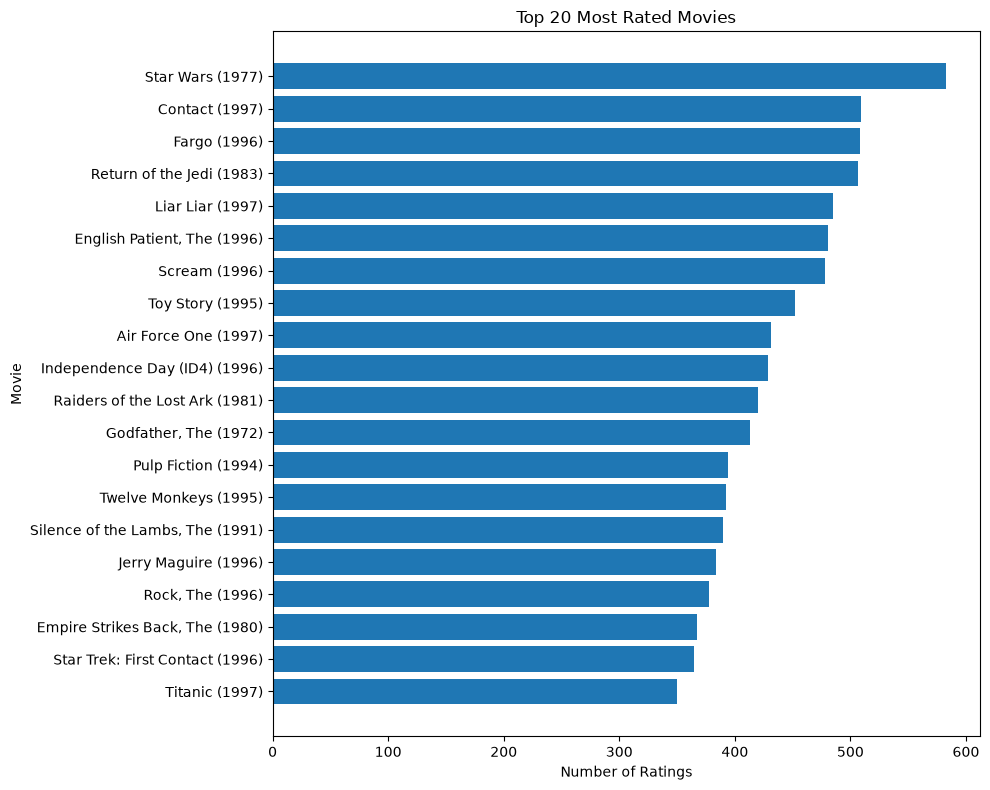

In [11]:
plt.figure(figsize=(10, 8))

plt.barh(
    top_movies["title"][::-1],
    top_movies["rating_count"][::-1]
)

plt.title("Top 20 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

## Investigate the long tail

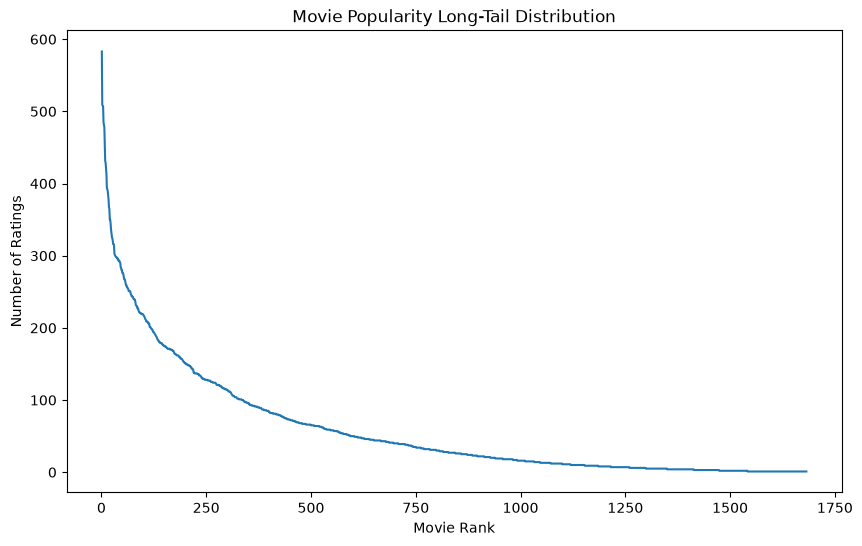

In [13]:
movie_counts = (
    ratings.groupby("movie_id")
    .size()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.plot(
    range(1, len(movie_counts) + 1),
    movie_counts
)

plt.title("Movie Popularity Long-Tail Distribution")
plt.xlabel("Movie Rank")
plt.ylabel("Number of Ratings")
plt.show()

### Quantify the long tail

In [14]:
thresholds = [5, 10, 20, 50, 100]

for threshold in thresholds:
    count = (movie_popularity < threshold).sum()

    print(
        f"Movies with fewer than {threshold} ratings: "
        f"{count}"
    )

Movies with fewer than 5 ratings: 333
Movies with fewer than 10 ratings: 530
Movies with fewer than 20 ratings: 743
Movies with fewer than 50 ratings: 1079
Movies with fewer than 100 ratings: 1344


### Analyze ratings over time

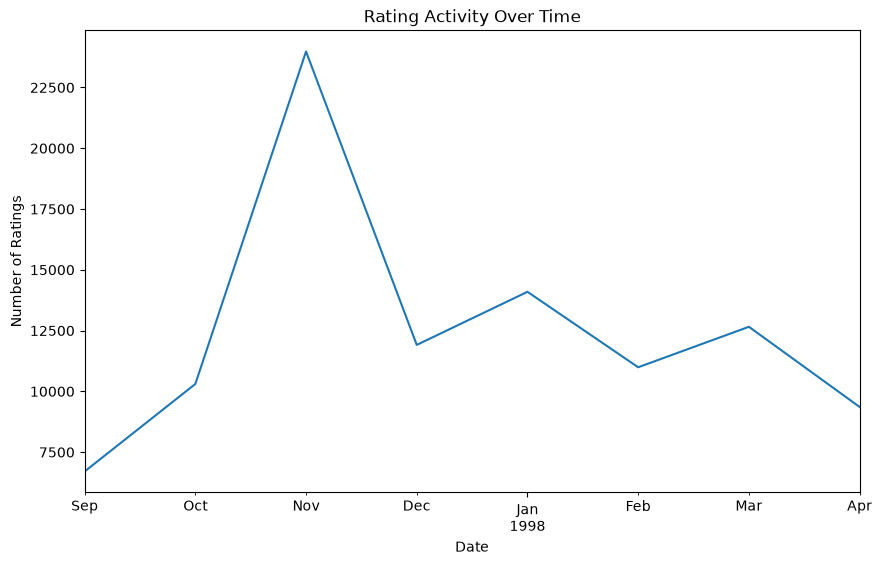

In [15]:
monthly_activity = (
    ratings
    .set_index("datetime")
    .resample("ME")
    .size()
)

monthly_activity.plot()

plt.title("Rating Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Ratings")
plt.show()

### Compare popularity vs rating quality

In [16]:
movie_stats = (
    ratings.groupby("movie_id")
    .agg(
        rating_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["movie_id", "title"]],
    on="movie_id",
    how="left"
)

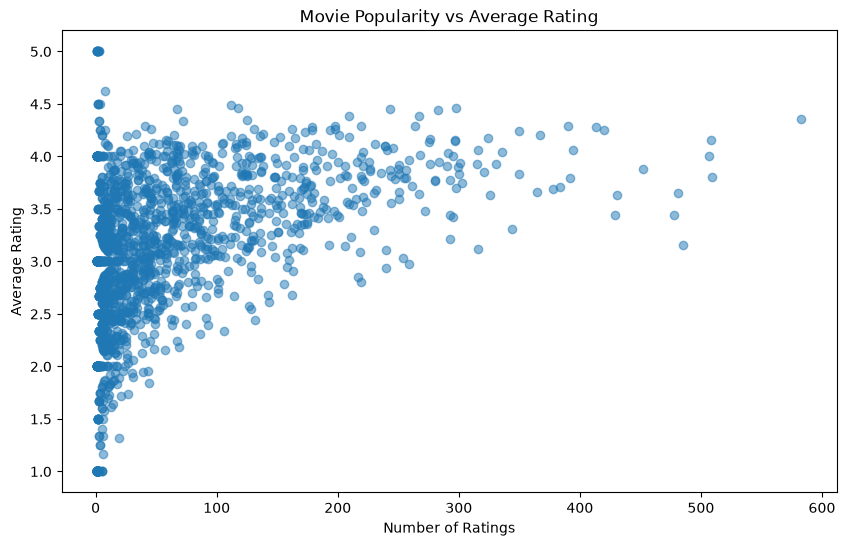

In [17]:
plt.scatter(
    movie_stats["rating_count"],
    movie_stats["average_rating"],
    alpha=0.5
)

plt.title("Movie Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

### Examine the bias directly

In [18]:
movie_stats[
    movie_stats["rating_count"] <= 5
].sort_values(
    "average_rating",
    ascending=False
).head(10)

,movie_id,rating_count,average_rating,title
1652,1653,1,5.0,Entertaining Angels: The Dorothy Day Story (1996)
813,814,1,5.0,"Great Day in Harlem, A (1994)"
1200,1201,1,5.0,Marlene Dietrich: Shadow and Light (1996)
1188,1189,3,5.0,Prefontaine (1997)
1292,1293,3,5.0,Star Kid (1997)
1121,1122,1,5.0,They Made Me a Criminal (1939)
1598,1599,1,5.0,Someone Else's America (1995)
1499,1500,2,5.0,Santa with Muscles (1996)
1466,1467,2,5.0,"Saint of Fort Washington, The (1993)"
1535,1536,1,5.0,Aiqing wansui (1994)


### Calculate the global rating

In [ ]:
global_mean = ratings["rating"].mean()

print(
    f"Global average rating: {global_mean:.3f}"
)

Global average rating: 3.530


: 